<a href="https://colab.research.google.com/github/Radiation444/CollegeUtility/blob/main/RideSharing_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
from datetime import datetime
import folium

# 1. Core Mathematical Logic
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
    a = math.sin((lat2_rad - lat1_rad) / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin((lon2_rad - lon1_rad) / 2)**2
    return R * (2 * math.asin(math.sqrt(a)))

def get_time_diff(t1, t2):
    return abs((datetime.strptime(t2, '%H:%M') - datetime.strptime(t1, '%H:%M')).total_seconds() / 60.0)

# 2. Database with Detailed Location Names for Popups
user_start = (26.4710, 73.1130)
user_end = (26.2810, 73.0230)
user_time = "17:00"

active_rides = {
    "User 1": {"start": (26.4740, 73.1160), "end": (26.2800, 73.0240), "time": "17:15", "start_name": "IITJ Hostel 2", "end_name": "Station Gate A"},
    "User 2": {"start": (26.4700, 73.1110), "end": (26.2820, 73.0220), "time": "16:50", "start_name": "IITJ Main Gate", "end_name": "Station Gate B"},
    "User 3": {"start": (26.4715, 73.1135), "end": (26.2810, 73.0230), "time": "19:00", "start_name": "IITJ Library", "end_name": "Station Gate A"},
    "User 4": {"start": (26.2400, 73.0000), "end": (26.2810, 73.0230), "time": "17:00", "start_name": "AIIMS Jodhpur", "end_name": "Station Gate A"},
    "User 5": {"start": (26.4710, 73.1130), "end": (26.3450, 73.0450), "time": "17:05", "start_name": "IITJ Hostel 1", "end_name": "Mandore Gardens"}
}

# 3. Phase 1: Map Initialization and Filtering
matched_group = [{"start": user_start, "end": user_end, "time": user_time, "start_name": "Base Origin", "end_name": "Base Dest"}]

midpoint = ((user_start[0] + user_end[0]) / 2, (user_start[1] + user_end[1]) / 2)
simulation_map = folium.Map(location=midpoint, zoom_start=11, tiles="OpenStreetMap")

# Base User Markers (Start and End)
base_popup_start = f"<b>Base User (Pickup)</b><br>Time: {user_time}<br>Origin: {user_start}"
base_popup_end = f"<b>Base User (Drop-off)</b><br>Time: {user_time}<br>Dest: {user_end}"
folium.Marker(user_start, popup=folium.Popup(base_popup_start, max_width=250), icon=folium.Icon(color="darkblue", icon="user")).add_to(simulation_map)
folium.Marker(user_end, popup=folium.Popup(base_popup_end, max_width=250), icon=folium.Icon(color="darkblue", icon="flag")).add_to(simulation_map)

print("--- PHASE 1: FILTERING DATABASE ---")
for ride_name, data in active_rides.items():
    s_dist = calculate_distance(user_start[0], user_start[1], data["start"][0], data["start"][1])
    e_dist = calculate_distance(user_end[0], user_end[1], data["end"][0], data["end"][1])
    t_diff = get_time_diff(user_time, data["time"])

    is_match = (s_dist <= 2.0) and (e_dist <= 5.0) and (t_diff <= 30)

    # Create detailed popup cards for BOTH pickup and drop-off
    popup_text_start = f"<b>{ride_name} (Pickup)</b><br>Time: {data['time']}<br>Location: {data['start_name']}"
    popup_text_end = f"<b>{ride_name} (Drop-off)</b><br>Time: {data['time']}<br>Location: {data['end_name']}"

    if is_match:
        print(f"✅ ACCEPTED [{ride_name}]: Added to shared pool.")
        matched_group.append(data)
        route_color = "green"
    else:
        reason = "Time" if t_diff > 30 else "Start Location" if s_dist > 2.0 else "End Location"
        print(f"❌ REJECTED [{ride_name}]: {reason} mismatch.")
        route_color = "red"

    # Plot Start Marker (Info-sign icon)
    folium.Marker(data["start"], popup=folium.Popup(popup_text_start, max_width=250), icon=folium.Icon(color=route_color, icon="info-sign")).add_to(simulation_map)

    # Plot End Marker (Flag icon to signify destination)
    folium.Marker(data["end"], popup=folium.Popup(popup_text_end, max_width=250), icon=folium.Icon(color=route_color, icon="flag")).add_to(simulation_map)

    # Draw the connecting line
    folium.PolyLine(locations=[data["start"], data["end"]], color=route_color, weight=3, opacity=0.6).add_to(simulation_map)

# 4. Phase 2: Dual Centroid Calculation
print("\n--- PHASE 2: CALCULATING DUAL CENTROIDS ---")
mean_start_lat = sum(u["start"][0] for u in matched_group) / len(matched_group)
mean_start_lon = sum(u["start"][1] for u in matched_group) / len(matched_group)
centroid_start = (mean_start_lat, mean_start_lon)

mean_end_lat = sum(u["end"][0] for u in matched_group) / len(matched_group)
mean_end_lon = sum(u["end"][1] for u in matched_group) / len(matched_group)
centroid_end = (mean_end_lat, mean_end_lon)

print(f"Pickup Centroid updated to: ({mean_start_lat:.4f}, {mean_start_lon:.4f})")
print(f"Drop-off Centroid updated to: ({mean_end_lat:.4f}, {mean_end_lon:.4f})")

# Draw the Start Centroid (Orange)
folium.Marker(centroid_start, popup="<b>Group Pickup Centroid</b>", icon=folium.Icon(color="orange", icon="star")).add_to(simulation_map)
folium.Circle(centroid_start, radius=2000, color="orange", fill=True, fill_opacity=0.2).add_to(simulation_map)

# Draw the End Centroid (Purple)
folium.Marker(centroid_end, popup="<b>Group Drop-off Centroid</b>", icon=folium.Icon(color="purple", icon="star")).add_to(simulation_map)
folium.Circle(centroid_end, radius=5000, color="purple", fill=True, fill_opacity=0.15).add_to(simulation_map)

# 5. Phase 3: Evaluate New User Against BOTH Centroids
print("\n--- PHASE 3: EVALUATING NEW USER AGAINST CENTROIDS ---")
new_user = {"start": (26.4720, 73.1140), "end": (26.2805, 73.0235), "time": "17:10", "start_name": "IITJ Sports Complex", "end_name": "Station Parking"}

ns_dist = calculate_distance(mean_start_lat, mean_start_lon, new_user["start"][0], new_user["start"][1])
ne_dist = calculate_distance(mean_end_lat, mean_end_lon, new_user["end"][0], new_user["end"][1])
nt_diff = get_time_diff(user_time, new_user["time"])

if ns_dist <= 2.0 and ne_dist <= 5.0 and nt_diff <= 30:
    print(f"🌟 SUCCESS: New User matched BOTH Centroids! Added to ride.")

    # Detailed popups for the new pooled user
    new_popup_start = f"<b>New User (Pooled Pickup)</b><br>Time: {new_user['time']}<br>Location: {new_user['start_name']}"
    new_popup_end = f"<b>New User (Pooled Drop-off)</b><br>Time: {new_user['time']}<br>Location: {new_user['end_name']}"

    folium.Marker(new_user["start"], popup=folium.Popup(new_popup_start, max_width=250), icon=folium.Icon(color="orange", icon="user")).add_to(simulation_map)
    folium.Marker(new_user["end"], popup=folium.Popup(new_popup_end, max_width=250), icon=folium.Icon(color="orange", icon="flag")).add_to(simulation_map)
    folium.PolyLine(locations=[new_user["start"], new_user["end"]], color="orange", weight=5, opacity=0.9).add_to(simulation_map)

# 6. Display Map
simulation_map

--- PHASE 1: FILTERING DATABASE ---
✅ ACCEPTED [User 1]: Added to shared pool.
✅ ACCEPTED [User 2]: Added to shared pool.
❌ REJECTED [User 3]: Time mismatch.
❌ REJECTED [User 4]: Start Location mismatch.
❌ REJECTED [User 5]: End Location mismatch.

--- PHASE 2: CALCULATING DUAL CENTROIDS ---
Pickup Centroid updated to: (26.4717, 73.1133)
Drop-off Centroid updated to: (26.2810, 73.0230)

--- PHASE 3: EVALUATING NEW USER AGAINST CENTROIDS ---
🌟 SUCCESS: New User matched BOTH Centroids! Added to ride.


--- INITIATING ALGORITHM STRESS TEST ---
Records Fetched (N)  | Processing Time (Seconds)
--------------------------------------------------
1,000                | 0.00232 seconds
5,000                | 0.00920 seconds
10,000               | 0.01881 seconds
50,000               | 0.09655 seconds
100,000              | 0.18958 seconds
500,000              | 0.95322 seconds
1,000,000            | 3.47472 seconds


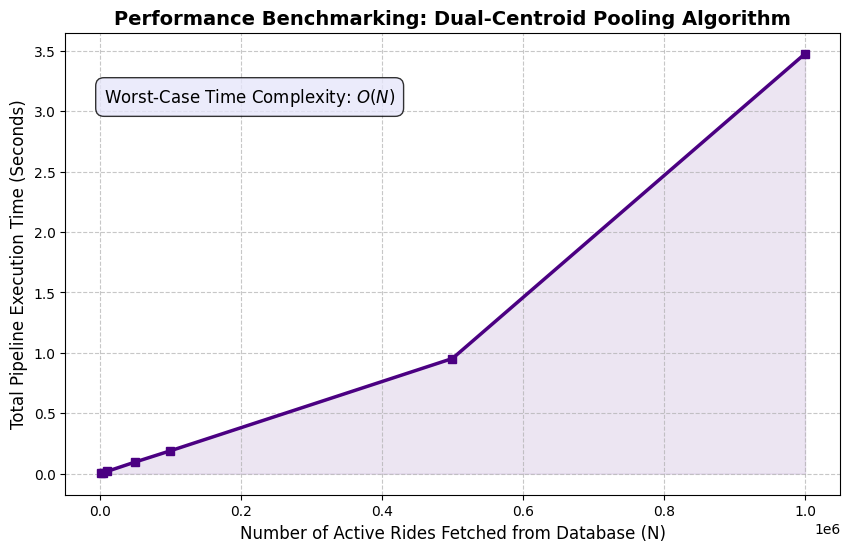

In [ ]:
import math
import time
import random
import matplotlib.pyplot as plt

# 1. Core Mathematical Logic
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
    a = math.sin((lat2_rad - lat1_rad) / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin((lon2_rad - lon1_rad) / 2)**2
    return R * (2 * math.asin(math.sqrt(a)))

def get_time_diff(t1, t2):
    # Simplified for the benchmark: using absolute integer difference for speed
    return abs(t1 - t2)

# 2. Database Simulator
def generate_simulated_database(size):
    # Generates a massive simulated database of rides fetched from a server
    db = []
    for _ in range(size):
        db.append({
            "start_lat": 26.0 + random.uniform(0, 1),
            "start_lon": 73.0 + random.uniform(0, 1),
            "end_lat": 26.0 + random.uniform(0, 1),
            "end_lon": 73.0 + random.uniform(0, 1),
            "time_mins": random.randint(0, 1440) # Random minute of the day
        })
    return db

# 3. The Complete Algorithm Lifecycle
def benchmark_pooling_lifecycle(database, base_user, new_user):
    matched_group = [base_user]

    # Phase 1: Fetch and Filter (O(N) operation)
    for ride in database:
        s_dist = calculate_distance(base_user["start_lat"], base_user["start_lon"], ride["start_lat"], ride["start_lon"])
        e_dist = calculate_distance(base_user["end_lat"], base_user["end_lon"], ride["end_lat"], ride["end_lon"])
        t_diff = get_time_diff(base_user["time_mins"], ride["time_mins"])

        if s_dist <= 2.0 and e_dist <= 5.0 and t_diff <= 30:
            matched_group.append(ride)

    # Phase 2: Dual Centroid Calculation (O(K) operation where K is matched pool size)
    k = len(matched_group)
    mean_s_lat = sum(u["start_lat"] for u in matched_group) / k
    mean_s_lon = sum(u["start_lon"] for u in matched_group) / k
    mean_e_lat = sum(u["end_lat"] for u in matched_group) / k
    mean_e_lon = sum(u["end_lon"] for u in matched_group) / k

    # Phase 3: Evaluate New User (O(1) operation)
    ns_dist = calculate_distance(mean_s_lat, mean_s_lon, new_user["start_lat"], new_user["start_lon"])
    ne_dist = calculate_distance(mean_e_lat, mean_e_lon, new_user["end_lat"], new_user["end_lon"])
    nt_diff = get_time_diff(base_user["time_mins"], new_user["time_mins"])

    is_pooled = (ns_dist <= 2.0 and ne_dist <= 5.0 and nt_diff <= 30)
    return is_pooled

# 4. Execute the Stress Test
database_sizes = [1000, 5000, 10000, 50000, 100000, 500000, 1000000]
execution_times = []

base_user = {"start_lat": 26.4710, "start_lon": 73.1130, "end_lat": 26.2810, "end_lon": 73.0230, "time_mins": 1020} # 17:00
new_user = {"start_lat": 26.4720, "start_lon": 73.1140, "end_lat": 26.2805, "end_lon": 73.0235, "time_mins": 1030} # 17:10

print("--- INITIATING ALGORITHM STRESS TEST ---")
print(f"{'Records Fetched (N)':<20} | {'Processing Time (Seconds)'}")
print("-" * 50)

for size in database_sizes:
    db = generate_simulated_database(size)

    start_time = time.perf_counter() # High-precision timer
    benchmark_pooling_lifecycle(db, base_user, new_user)
    end_time = time.perf_counter()

    exec_time = end_time - start_time
    execution_times.append(exec_time)
    print(f"{size:<20,d} | {exec_time:.5f} seconds")

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(database_sizes, execution_times, marker='s', linestyle='-', color='indigo', linewidth=2.5)

plt.title('Performance Benchmarking: Dual-Centroid Pooling Algorithm', fontsize=14, fontweight='bold')
plt.xlabel('Number of Active Rides Fetched from Database (N)', fontsize=12)
plt.ylabel('Total Pipeline Execution Time (Seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.fill_between(database_sizes, execution_times, color='indigo', alpha=0.1)

plt.text(0.05, 0.85, "Worst-Case Time Complexity: $O(N)$",
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lavender", alpha=0.8))

plt.show()